# 1. Wczytanie danych

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import aseegg as ag 
import numpy as np
import random
from scipy.signal import find_peaks

plt.rcParams["figure.figsize"] = (10, 4)

In [29]:
df = pd.read_csv("ganglion_4ch_2025-12-04_12-28-43.csv")

In [30]:
df

,time,ch1,ch2,ch3,ch4
0,1.764848e+09,-214.864732,-145.764471,-153.408826,-148.591835
1,1.764848e+09,37.335421,-424.308480,-426.350465,-433.845224
2,1.764848e+09,-12.188334,3.588434,2.036376,0.906926
3,1.764848e+09,-206.872566,-151.997014,-160.688541,-154.764540
4,1.764848e+09,-176.130588,-592.373974,-604.304255,-599.378806
...,...,...,...,...,...
7643,1.764848e+09,137.057984,1335.937143,1335.379898,1341.062676
7644,1.764848e+09,115.972428,1320.252003,1318.662545,1316.641129
7645,1.764848e+09,304.418507,1006.298621,1008.280768,1005.511372
7646,1.764848e+09,335.332520,1039.550071,1049.946993,1047.712403


# 2. Utworzenie sygnału w dziedzinie czasu

In [31]:
len(df["ch1"]) #liczba próbek sygnału

7648

In [32]:
len(df["ch1"])/200 #liczba próbek sygnału : częstotliwość próbkowania 200Hz; całkowity czas trwania sygnału w sekundach

38.24

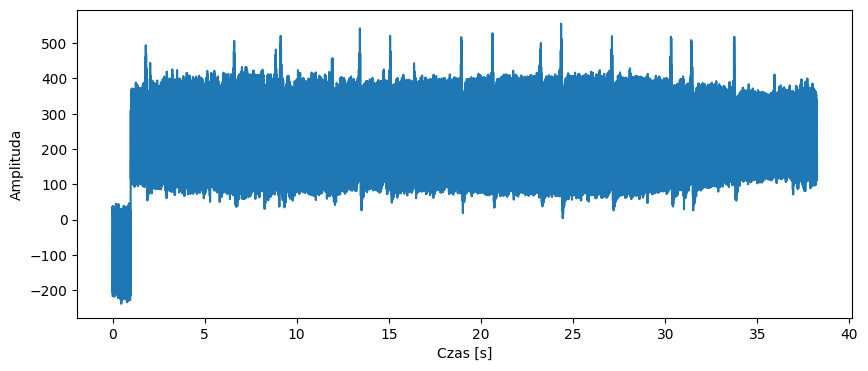

In [33]:
t_axis = np.linspace(0, 38.24, len(df["ch1"])) #sygnał z elektrody "ch1"; czas w sekundach dla każdej próbki sygnału
plt.plot(t_axis, df["ch1"])
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda")
plt.show() #wykres w dziedzinie czasu

# 3. Utworzenie sygnału w dziedzinie częstotliwości

Text(0, 0.5, 'Amplituda')

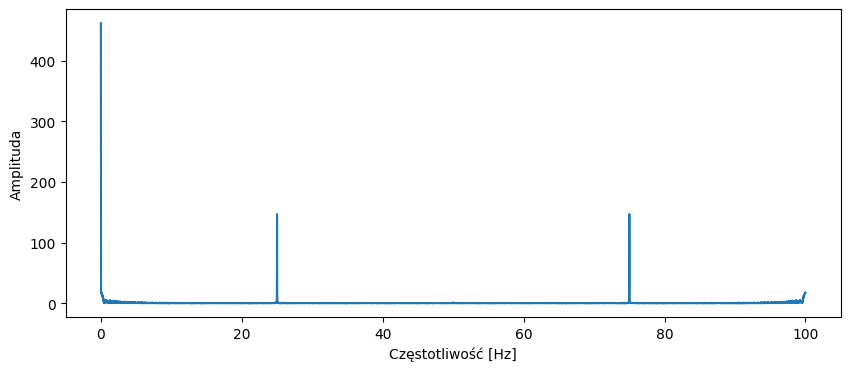

In [34]:
ffted = ag.FFT(df["ch1"]) #jak samo df to dla wszystkich sygnalow
f_axis = np.linspace(0, 100, len(ffted)) #100 bo fs (czestotliwosc probkowania) : 2 = maksymalna czestotliwosc (tutaj 100)
plt.plot(f_axis,ffted)
#w wykresie czestotliwosci
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Amplituda")

# 4. Wskazanie zakłóceń

### 4.1. zakłócenie pierwsze (0 Hz)

(-10.0, 500.0)

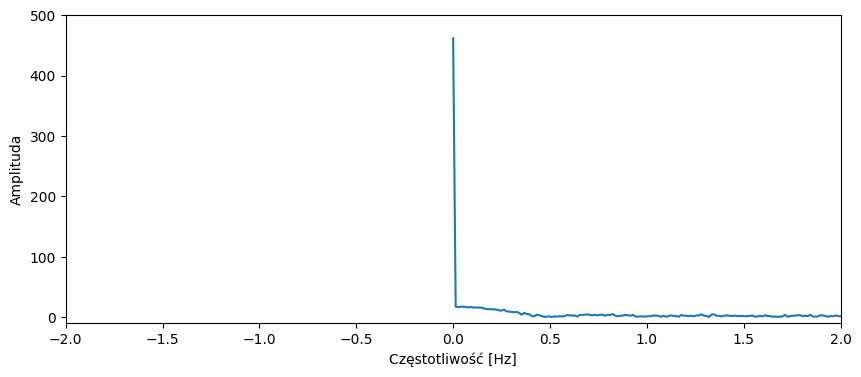

In [35]:
f_axis = np.linspace(0, 100, len(ffted))
ffted = ag.FFT(df["ch1"])
plt.plot(f_axis, ffted)
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Amplituda")
#zakłócenie 1
plt.xlim([-2,2])
plt.ylim([-10,500])

### 4.2. zakłócenie drugie (25 Hz)

(-10.0, 150.0)

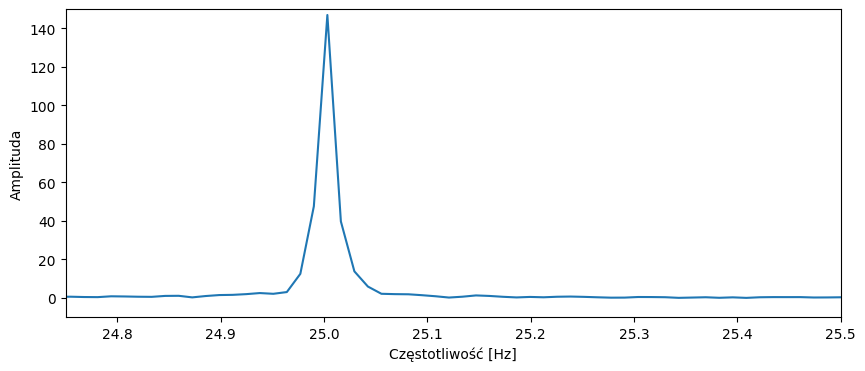

In [36]:
f_axis = np.linspace(0, 100, len(ffted))
ffted = ag.FFT(df["ch1"])
plt.plot(f_axis, ffted)
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Amplituda")
#zakłócenie 2
plt.xlim([24.75,25.50])
plt.ylim([-10,150])

### 4.3. zakłócenie trzecie (75 Hz)

(-10.0, 150.0)

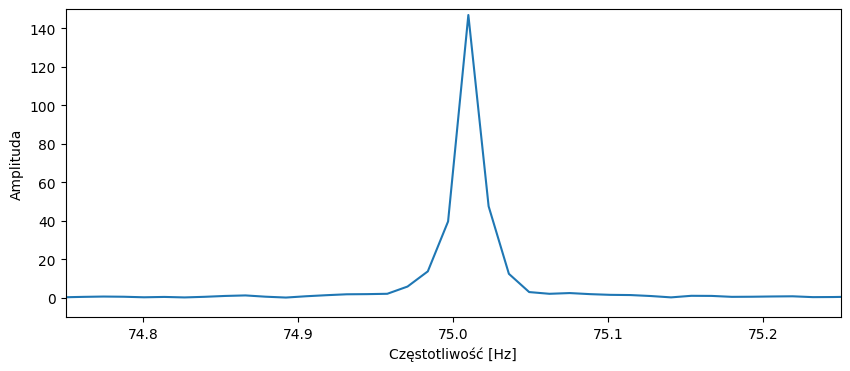

In [37]:
f_axis = np.linspace(0, 100, len(ffted))
ffted = ag.FFT(df["ch1"])
plt.plot(f_axis, ffted)
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Amplituda")
#zakłócenie 3
plt.xlim([74.75,75.25])
plt.ylim([-10,150])

# 5. Usunięcie zakłóceń (filtracja)

Text(0, 0.5, 'Amplituda')

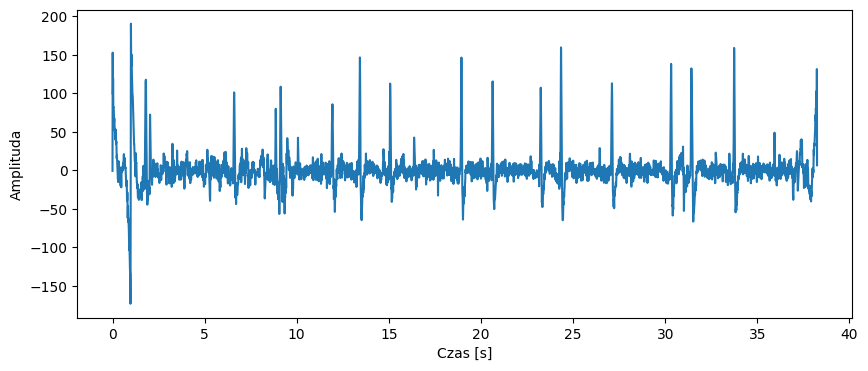

In [ ]:
zaklocenie1 = df["ch1"].values
filtracja1 = ag.gornoprzepustowy(zaklocenie1,200,1) #usuniecie pierwszego zakłócenia
filtracja2 = ag.pasmowozaporowy(filtracja1,200,48,52) #usuniecie drugiego zakłócenia
filtracja3 = ag.pasmowoprzepustowy(filtracja2,200,1,40) #usuniecie trzeciego zakłócenia

t_axis = np.linspace(0, len(filtracja3)/200, len(filtracja3))
plt.plot(t_axis,filtracja3)
plt.xlabel('Czas [s]')
plt.ylabel('Amplituda')

### 5.1. przybliżenie dowolnego mrugnięcia

(-70.0, 150.0)

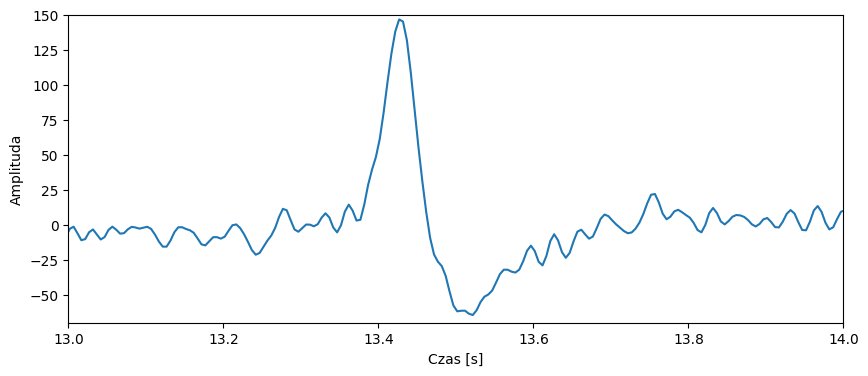

In [39]:
t_axis = np.linspace(0, len(filtracja3)/200, len(filtracja3))
plt.plot(t_axis,filtracja3)
plt.xlabel('Czas [s]')
plt.ylabel('Amplituda')
plt.xlim([13,14])
plt.ylim([-70,150])

# 6. Epokowanie (względem triggera - moment mrugnięcia)

### 6.1. ustalenie ilości mrugnięć

In [ ]:
sygnal = df["ch1"].values
sygnal = sygnal - np.mean(sygnal)
czest_prob = 200 #częstotliwość próbkowania

from scipy.signal import butter, filtfilt

b, a = butter(2, [0.5, 4], btype="bandpass", fs=czest_prob)
sygnal_f = filtfilt(b, a, sygnal)

thr = 1.5 * np.std(sygnal_f) #próg amplitudy, jej wartość graniczna

peaks, _ = find_peaks(
    np.abs(sygnal_f),
    height=thr,
    distance=int(0.8 * 200)
)

len(peaks) #ilość wykrytych mrugnięć

16

### 6.2. wizualizacja ilości mrugnięć

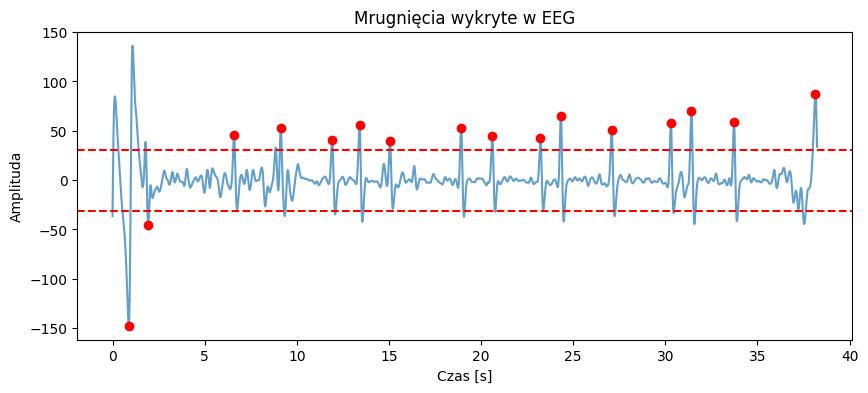

In [41]:
t = np.arange(len(sygnal)) / czest_prob

plt.figure()
plt.plot(t, sygnal_f, alpha=0.7)
plt.plot(peaks / czest_prob, sygnal_f[peaks], "ro")
plt.axhline(thr, color="r", linestyle="--")
plt.axhline(-thr, color="r", linestyle="--")
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda")
plt.title("Mrugnięcia wykryte w EEG")
plt.show()

### 6.3. ustalenie czasu trwania mrugnięcia i epok

In [ ]:
czas_min = -0.3   #czas [s] przed mrugnięciem 
czas_max = 0.6    #czas [s] po mrugnięciu
#0,9s -> ogólny czas trwania mrugnięcia 

In [43]:
samp_min = int(czas_min * czest_prob)
samp_max = int(czas_max * czest_prob)
epoki = []

for p in peaks:
    start = p + samp_min
    stop = p + samp_max

    if start >= 0 and stop < len(sygnal):
        epoki.append(sygnal[start:stop])

epoki = np.array(epoki)

epoki.shape #liczba epok, czas epoki

(15, 180)

### 6.4. epokowanie

In [44]:
czas_mrugniec = peaks / czest_prob
print(czas_mrugniec, "s")
#czasy, w których wykonano mrugnięcia

[ 0.885  1.935  6.595  9.13  11.92  13.405 15.06  18.92  20.615 23.225
 24.335 27.09  30.3   31.415 33.73  38.15 ] s


In [ ]:
czas_unix = []
with open("bodźce_czas.txt", "r") as f:
    for linia in f:
        parts = linia.strip().split(",")
        czas_unix.append(float(parts[2]))

czas_unix = np.array(czas_unix)

#zmiana czasu na sekundy względem początku sygnału EEG
czas_s = czas_unix - czas_unix[0]

print(czas_s)

#czas, w którym wyświetlone zostały bodźce

[   0.            2.60776305    5.21753716    7.84257197 1043.79952717
 1046.42946005 1157.54291797 1160.15697813 1162.75782013 1165.34662199
 1167.92260313 1267.51491714 1270.36085105 1272.95204115 1275.49964118
 1278.09391713 1280.73568296 1283.328197   1285.93344998 1751.53375912
 1754.11514401 1756.66189098 1759.25098896 1761.85163307 1764.43471098
 1767.17065406 1769.78402305]


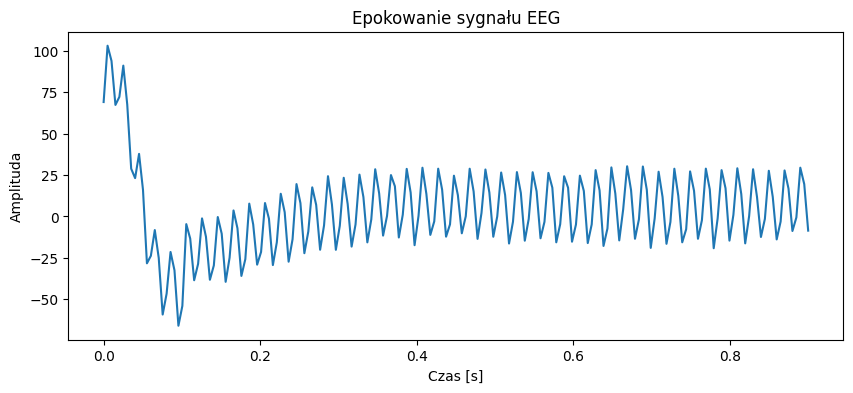

In [46]:
indeksy_bodzcow = (czas_mrugniec * czest_prob).astype(int)

okno = 180
num_epok = len(indeksy_bodzcow)
sredni_sygnal = np.zeros(okno)

for i in range(num_epok):
    start = indeksy_bodzcow[i]
    stop = start + okno
    if stop <= len(sygnal):
        fragment = sygnal[start:stop]
        sredni_sygnal += fragment

sredni_sygnal /= num_epok

t = np.linspace(0, okno/czest_prob, okno)
plt.plot(t, sredni_sygnal)
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda")
plt.title("Epokowanie sygnału EEG")
plt.show()

# 7. Porównanie uzyskanych danych

In [47]:
bodzce = []
with open("bodźce_czas.txt", "r") as f:
    for line in f:
        line = line.strip()
        if line:
            nazwa, plik, czas_unix = line.split(",")
            bodzce.append((nazwa, plik, float(czas_unix)))


start_unix = 1764847723.3031328  #czas rozpoczęcia nagrania EEG w formacie UNIX
bodzce_od_nagrania = [(n, p, czas_unix - start_unix) for (n, p, czas_unix) in bodzce]


okno_2 = 1  #zaokrąglony czas trwania pojedynczego mrugnięcia

print("Wyniki porównania mrugnięć z bodźcami:\n")
for n, p, bodzce_czas in bodzce_od_nagrania:
    mrugniecia_przy_bodzcu = czas_mrugniec[(czas_mrugniec >= bodzce_czas - okno_2) & (czas_mrugniec <= bodzce_czas + okno_2)]
    
    #średni czas reakcji względem bodźca (jeśli są mrugnięcia)
    if len(mrugniecia_przy_bodzcu) > 0:
        czas_reakcji = mrugniecia_przy_bodzcu - bodzce_czas
        srednia_reakcji = np.mean(czas_reakcji)
    else:
        czas_reakcji = np.array([])
        srednia_reakcji = None
    
    print(f"Bodziec: {p}")
    print(f"  Czas od początku EEG: {bodzce_czas:.3f}s")
    print(f"  Mrugnięcia w oknie ±{okno_2}s: {mrugniecia_przy_bodzcu}")
    if srednia_reakcji is not None:
        print(f"  Średni czas reakcji: {srednia_reakcji:.3f}s\n")
    else:
        print(f"  Brak mrugnięć w oknie bodźca\n")


Wyniki porównania mrugnięć z bodźcami:

Bodziec: biuro4.png
  Czas od początku EEG: -1258.011s
  Mrugnięcia w oknie ±1s: []
  Brak mrugnięć w oknie bodźca

Bodziec: biuro1.png
  Czas od początku EEG: -1255.403s
  Mrugnięcia w oknie ±1s: []
  Brak mrugnięć w oknie bodźca

Bodziec: biuro2.png
  Czas od początku EEG: -1252.793s
  Mrugnięcia w oknie ±1s: []
  Brak mrugnięć w oknie bodźca

Bodziec: biuro3.png
  Czas od początku EEG: -1250.168s
  Mrugnięcia w oknie ±1s: []
  Brak mrugnięć w oknie bodźca

Bodziec: freddy3.gif
  Czas od początku EEG: -214.211s
  Mrugnięcia w oknie ±1s: []
  Brak mrugnięć w oknie bodźca

Bodziec: biuro3.png
  Czas od początku EEG: -211.582s
  Mrugnięcia w oknie ±1s: []
  Brak mrugnięć w oknie bodźca

Bodziec: freddy3.gif
  Czas od początku EEG: -100.468s
  Mrugnięcia w oknie ±1s: []
  Brak mrugnięć w oknie bodźca

Bodziec: freddy4.gif
  Czas od początku EEG: -97.854s
  Mrugnięcia w oknie ±1s: []
  Brak mrugnięć w oknie bodźca

Bodziec: biuro3.png
  Czas od pocz